# Assignment 2

### MLP and $k$-distance

_Submission deadline: **14.12.2025**_

---

#### Submission Information

Upload your solution via the VC course. Please upload **one zip archive** per group. This must contain:

- Your solution as a **Notebook** (a `.ipynb` file)
- At least the file ``MLP.py`` for task 02.1.1.
- A folder **images** with all your images (keep the image sizes relatively small)

Your zip file should be named according to the following scheme:

```
assignment_<assignment number>_solution_<group number>.zip
```

In this assignment you can achieve a total of **55** points. These points translate into **2.5 bonus points** for the exam as follows:

| **Points in Assignment** | **Bonus Points for Exam** |
| :-: | :-: |
| 52 | 2.5 |
| 44 | 2.0 |
| 36 | 1.5 |
| 28 | 1.0 |
| 20 | 0.5 |

<div class='alert alert-block alert-danger'>

##### **Important Notes**

1. **This assignment will be graded. You can earn bonus points for the exam.**
2. **If it is obvious to us that a task was copied from another source and no independent work was performed, we will not award any bonus points. Formulate all answers in your own words!**
3. **If LLMs (such as ChatGPT or CoPilot) were used to create your submission, please indicate this at the respective places. Also observe the [AI-Policy](https://cogsys.uni-bamberg.de/teaching/ki-richtlinie.html).**

---

### 1 | MLP

_For a total of 37 points_

### **(02.1.1)** Backpropagation

_For **31** points_

In this task, you should develop your own Python package that implements a Multilayer Perceptron (MLP). You will later use this package in the notebook to classify the Iris dataset. The goal of the task is to understand and implement the basic computation steps of a neural network with at least one hidden layer yourself. A simple Perceptron is already available in the file `perceptron.py`. First, familiarize yourself with the implementation of this file.

The focus in the following is on implementing the backpropagation algorithm. For this, you should program two methods in the file `MLP.py`:

- `fit`: This method should perform the actual training process over multiple epochs.
- `backprop`: This method should calculate gradients for all weights and biases.

The signatures as well as additional methods are already contained in `MLP.py`. Familiarize yourself with these first. You will need them for your following implementation. A special feature is the one-hot encoding of class labels, which is done by the `__one_hot` method. One-hot encoding is a simple method to represent categories numerically. This is necessary to output an activation in the form of a vector at the end.

To enable a fast but still algorithm-oriented implementation, the weights are stored twice: once in the individual perceptrons of the layers, and once as a collected weight matrix that enables fast calculations. In order for your weight adjustments to be implemented, update the weights of the individual perceptrons (``Perceptron.update_weights()``) according to the backpropagation algorithm, and use the method ``MLP.update_matrices()`` to transfer the new weights into the matrices before you calculate a forward pass again.


### **(02.1.2)** Test Implementation with Iris Dataset

_For **6** points_

Once you have implemented the previous implementation, the `KogSysMLP` Python package can be installed using `pip`. To do this, change to the directory `KogSysMLP/` and execute the following command:

```bash
pip install -e .
```

In the next code cell, the Python package just installed is loaded. The following libraries are also imported:

- `sklearn.datasets.load_iris`: Loads the Iris dataset.
- `sklearn.model_selection.train_test_split`: Splits datasets into training and test data.
- `sklearn.preprocessing.StandardScaler`: Scales the features of the dataset.

**_Nothing needs to be changed in the next code cell._**

In [6]:
# Library imports

import KogSysMLP

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Now we will test with the Iris dataset. For this purpose, it is loaded in the following cell.

**_Nothing needs to be changed in the next code cell._**

In [7]:
iris = load_iris()
X = iris.data
y = iris.target

First scale the dataset with the `StandardScaler` and then split it using `train_test_split` into training and test data. Use 20% of the data as the test set and a `random_state = 42` so that the split remains reproducible.

In [8]:
# 2 Points

# ==============================================================================
# STEP 1: Scale the features using StandardScaler
# ==============================================================================
# WHY: Neural networks work better when features are on similar scales.
#      StandardScaler transforms features to have mean=0 and standard deviation=1.
#
# Example: Iris features have different ranges:
#   - Sepal length: 4.3 to 7.9 cm
#   - Petal width: 0.1 to 2.5 cm
# After scaling, all features will be roughly in the range [-3, 3]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
# fit_transform: learns the mean and std from X, then applies the transformation
X_scaled = scaler.fit_transform(X)


# ==============================================================================
# STEP 2: Split into training and test sets
# ==============================================================================
# WHY: We need separate data to evaluate how well the model generalizes.
#      Training set: used to train the model (learn weights)
#      Test set: used to evaluate final performance (never seen during training)
#
# Parameters:
#   - test_size=0.2: Use 20% of data for testing, 80% for training
#   - random_state=42: Makes the split reproducible (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,           # Scaled features
    y,                  # Labels (0, 1, 2 for the three Iris species)
    test_size=0.2,      # 20% for testing
    random_state=42     # Seed for reproducibility
)

# Summary:
# - X_train: 120 samples for training (80% of 150)
# - X_test: 30 samples for testing (20% of 150)
# - y_train: labels for training samples
# - y_test: labels for test samples

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Test set size: 30 samples


Now initialize the implemented MLP. First test the parameters yourself. Try to maximize the accuracy, which you should implement in the following code block. A learning rate in the low range (e.g., between 0.01 and 0.1) and several thousand epochs are often a sensible starting point.

In [9]:
# 3 Points

# ==============================================================================
# STEP 1: Initialize the MLP
# ==============================================================================
# WHY: We need to configure the network architecture before training.
#
# Parameters to consider:
#   - hidden_layers: List of hidden layer sizes
#     Example: [10] = one hidden layer with 10 neurons
#              [20, 10] = two hidden layers with 20 and 10 neurons
#
# For Iris dataset:
#   - Input: 4 features (sepal length, sepal width, petal length, petal width)
#   - Hidden: We choose the number of neurons (experiment with different values)
#   - Output: 3 classes (setosa, versicolor, virginica) - set automatically

# Create MLP with one hidden layer of 10 neurons
# Feel free to experiment with different architectures like [20], [15, 10], etc.
mlp = KogSysMLP.MLP(hidden_layers=[10])

print(f"MLP initialized with hidden layers: {mlp.hidden}")


# ==============================================================================
# STEP 2: Train the MLP
# ==============================================================================
# WHY: Training adjusts the weights through backpropagation to minimize errors.
#
# Parameters:
#   - X_train: Training features
#   - y_train: Training labels
#   - lr: Learning rate (how big the weight updates are)
#         - Too small: slow learning
#         - Too large: unstable learning, might not converge
#   - max_epoch: Number of training iterations through the entire dataset
#         - More epochs: better learning but takes longer
#         - Too few: underfitting (doesn't learn enough)
#         - Too many: might overfit (memorizes training data)
#
# Recommended starting points:
#   - lr: 0.01 to 0.1
#   - max_epoch: 1000 to 5000

print("Training the MLP...")

# Train the model
# Experiment with these parameters to maximize accuracy!
mlp.fit(
    X_train,            # Training data
    y_train,            # Training labels
    lr=0.05,           # Learning rate (try adjusting: 0.01, 0.05, 0.1)
    max_epoch=3000      # Number of epochs (try: 1000, 3000, 5000)
)

print("Training complete!")

MLP initialized with hidden layers: [10]
Training the MLP...
Training complete!


After training, calculate the accuracy of your MLP on the test data. Use the model's predictions and compare them with the actual labels.

In [10]:
# 1 Point

# Import numpy for array operations
import numpy as np

# ==============================================================================
# Calculate accuracy on test data
# ==============================================================================
# WHY: Accuracy tells us how well the model performs on unseen data.
#      This is the true measure of how well the model has learned.
#
# Formula: Accuracy = (Number of correct predictions) / (Total predictions)
#
# Example: If we predict 27 out of 30 test samples correctly:
#          Accuracy = 27/30 = 0.9 = 90%

# Step 1: Make predictions on test data
# The predict() method returns class labels (0, 1, or 2)
y_pred = mlp.predict(X_test)

# Step 2: Compare predictions with actual labels
# y_pred[i] == y_test[i] returns True if correct, False if wrong
# np.sum() counts the number of True values (correct predictions)
correct_predictions = np.sum(y_pred == y_test)

# Step 3: Calculate accuracy as a percentage
total_predictions = len(y_test)
accuracy = correct_predictions / total_predictions

# Display results
print(f"\n{'='*50}")
print(f"MLP Test Results on Iris Dataset")
print(f"{'='*50}")
print(f"Total test samples: {total_predictions}")
print(f"Correct predictions: {correct_predictions}")
print(f"Incorrect predictions: {total_predictions - correct_predictions}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*50}")

# Interpretation:
# - Accuracy close to 1.0 (100%): Excellent! Model learned well
# - Accuracy around 0.7-0.9 (70-90%): Good, but could be improved
# - Accuracy below 0.7 (70%): Poor, try adjusting hyperparameters
#
# Tips to improve accuracy:
# 1. Increase max_epoch (more training)
# 2. Adjust learning rate (try 0.01, 0.05, 0.1)
# 3. Change hidden layer size (try [5], [15], [20, 10])
# 4. Multiple runs (neural networks have random initialization)


MLP Test Results on Iris Dataset
Total test samples: 30
Correct predictions: 30
Incorrect predictions: 0
Accuracy: 1.0000 (100.00%)


---
### 2 | Local Outlier Factor

_For a total of **18** points_

To detect outliers from clusters, a $k$-distance approach can be implemented based on the $k$-Nearest-Neighbors algorithm. The basic principle of this so-called Local Outlier Factor can be read [here in the Wikipedia article](https://en.wikipedia.org/wiki/Local_Outlier_Factor). Familiarize yourself with this approach!

The goal of this task is to implement the $k$-distance algorithm.

At the end of the task there is a test block with which you can test your implementation.

### **(02.2.1)** Determining the Distance

_For **6** points_

The distances between the individual points should be calculated according to their Euclidean distance. The Euclidean distance is defined as
$$d(x_i, x_j) \equiv \sqrt{\sum_{r=1}^{n}\left(a_r(x_i) - a_r(x_j)\right)^2}.$$

To calculate this value, implement the function `euclidean_distance()`. The function `pairwise_distances()` should then calculate the pairwise Euclidean distances of a point set and return them as a matrix.

In [11]:
import numpy as np

def euclidean_distance(x1, x2):
    """
    Calculate the Euclidean distance between two points.
    
    The Euclidean distance is the straight-line distance between two points.
    Formula: d = sqrt((x1[0] - x2[0])^2 + (x1[1] - x2[1])^2 + ...)
    
    Example:
    - x1 = [0, 0], x2 = [3, 4]
    - distance = sqrt((0-3)^2 + (0-4)^2) = sqrt(9 + 16) = sqrt(25) = 5
    
    Parameters
    ----------
    x1 : array-like
        First point (can be 1D array of features)
    x2 : array-like
        Second point (same dimensions as x1)
    
    Returns
    -------
    float
        The Euclidean distance between x1 and x2
    """
    # Step 1: Calculate differences for each dimension
    # Example: [0, 0] - [3, 4] = [-3, -4]
    diff = x1 - x2
    
    # Step 2: Square each difference
    # Example: [-3, -4]^2 = [9, 16]
    squared_diff = diff ** 2
    
    # Step 3: Sum all squared differences
    # Example: 9 + 16 = 25
    sum_squared = np.sum(squared_diff)
    
    # Step 4: Take square root
    # Example: sqrt(25) = 5
    distance = np.sqrt(sum_squared)
    
    return distance


def pairwise_distances(X):
    """
    Calculate pairwise Euclidean distances for all points in X.
    
    This creates a distance matrix where element [i, j] is the distance
    between point i and point j.
    
    Example for 3 points:
    - Points: [[0, 0], [1, 0], [0, 1]]
    - Result: [[0.0, 1.0, 1.0],
               [1.0, 0.0, 1.41],
               [1.0, 1.41, 0.0]]
    
    WHY: We need this to find nearest neighbors for each point.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Set of points
    
    Returns
    -------
    ndarray, shape (n_samples, n_samples)
        Distance matrix where element [i, j] = distance(X[i], X[j])
    """
    # Get number of points
    n_samples = X.shape[0]
    
    # Create empty matrix to store distances
    # Shape: (n_samples, n_samples)
    distances = np.zeros((n_samples, n_samples))
    
    # Calculate distance between every pair of points
    # Nested loop: for each point i, calculate distance to every point j
    for i in range(n_samples):
        for j in range(n_samples):
            # Distance from point i to point j
            distances[i, j] = euclidean_distance(X[i], X[j])
    
    # The diagonal (i==j) will be 0 (distance from a point to itself)
    # Matrix is symmetric: distances[i, j] == distances[j, i]
    return distances

### **(02.2.2)** k-Distance Implementation

_For **12** points_

Now implement the `k_distance` class. Base yourself on the fundamentals of the k-nearest-neighbor algorithm (as learned in the lecture and exercise) and adapt it with the formulas explained in the Wikipedia article ([Local Outlier Factor](https://en.wikipedia.org/wiki/Euclidean_distance)). 

The class should contain the methods `fit()` and `predict()`. Additional helper functions (for example, to calculate the values of the Local Outlier Factor) can make the class more manageable.

In [12]:
class k_distance:
    """
    Local Outlier Factor (LOF) detector using k-nearest neighbors.
    
    LOF ALGORITHM OVERVIEW:
    -----------------------
    The Local Outlier Factor measures how isolated a point is compared to
    its neighbors. A point is an outlier if it's far from its neighbors
    while its neighbors are close to each other.
    
    Main steps:
    1. For each point, find its k nearest neighbors
    2. Calculate k-distance: distance to the k-th nearest neighbor
    3. Calculate reachability distance: max of actual distance and k-distance
    4. Calculate Local Reachability Density (LRD): inverse of average reachability
    5. Calculate LOF: ratio of neighbor LRDs to point's LRD
    
    LOF Score Interpretation:
    - LOF ≈ 1: Point has similar density as neighbors (normal)
    - LOF > 1: Point has lower density than neighbors (outlier)
    - LOF >> 1: Point is a strong outlier
    """
    
    def __init__(self, k):
        """
        Initialize the LOF detector.
        
        Parameters
        ----------
        k : int
            Number of nearest neighbors to use
            Higher k = smoother, more global outlier detection
            Lower k = more sensitive to local anomalies
        """
        self.k = k
        self.x_train = None

    def fit(self, X):
        """
        Store training data for LOF computation.
        
        WHY: LOF is computed on the training data itself. Each point's
        outlier score depends on its relationship to other points in the dataset.
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training samples to be used for LOF computation.
        """
        # Simply store the training data
        # We'll use it in predict() to compute LOF scores
        self.x_train = X
    
    def predict(self):
        """
        Compute LOF scores for the stored training data.
        
        This implements the full LOF algorithm:
        1. Calculate pairwise distances
        2. Find k-nearest neighbors for each point
        3. Calculate reachability distances
        4. Calculate Local Reachability Density (LRD)
        5. Calculate LOF scores
        
        Returns
        -------
        lof : ndarray, shape (n_samples,)
            Local Outlier Factor score for each sample.
            Higher values = more likely to be outliers
        neigh_idx : ndarray, shape (n_samples, k)
            Indices of the k nearest neighbors for each sample.
        """
        # ====================================================================
        # STEP 1: Calculate pairwise distances between all points
        # ====================================================================
        # WHY: We need to know how far each point is from every other point
        #      to find the nearest neighbors.
        
        distances = pairwise_distances(self.x_train)
        n_samples = self.x_train.shape[0]
        
        
        # ====================================================================
        # STEP 2: Find k-nearest neighbors for each point
        # ====================================================================
        # WHY: LOF is based on comparing a point's density with its neighbors' density.
        
        # For each point, we need to find the indices of its k nearest neighbors
        # We'll also store the k-distances (distance to k-th nearest neighbor)
        
        neigh_idx = np.zeros((n_samples, self.k), dtype=int)
        k_distances = np.zeros(n_samples)
        
        for i in range(n_samples):
            # Get distances from point i to all other points
            dists_from_i = distances[i]
            
            # Sort the distances and get the indices
            # argsort returns indices that would sort the array
            # Example: [5, 2, 8, 1] -> argsort gives [3, 1, 0, 2]
            sorted_indices = np.argsort(dists_from_i)
            
            # Take the k+1 nearest (we exclude the point itself at index 0)
            # The first index is the point itself (distance 0), so skip it
            nearest_k = sorted_indices[1:self.k + 1]
            
            # Store the k nearest neighbor indices
            neigh_idx[i] = nearest_k
            
            # k-distance is the distance to the k-th nearest neighbor
            # This is the furthest of the k nearest neighbors
            k_distances[i] = dists_from_i[nearest_k[-1]]
        
        
        # ====================================================================
        # STEP 3: Calculate reachability distances
        # ====================================================================
        # WHY: Reachability distance smooths out statistical fluctuations.
        #      It's the "real" distance or the k-distance of the neighbor,
        #      whichever is larger.
        #
        # FORMULA: reach_dist(A, B) = max(k_distance(B), actual_distance(A, B))
        #
        # INTUITION: If B is in a dense region (small k-distance), we use
        #            B's k-distance. This makes LOF more stable.
        
        # We'll calculate this on-the-fly when computing LRD
        
        
        # ====================================================================
        # STEP 4: Calculate Local Reachability Density (LRD) for each point
        # ====================================================================
        # WHY: LRD measures how dense the neighborhood around a point is.
        #      High LRD = point is in a dense region
        #      Low LRD = point is isolated
        #
        # FORMULA: LRD(A) = 1 / (average reachability distance of A to its neighbors)
        
        lrd = np.zeros(n_samples)
        
        for i in range(n_samples):
            # Get the k nearest neighbors of point i
            neighbors = neigh_idx[i]
            
            # Calculate reachability distance from point i to each neighbor
            reach_dists = []
            for neighbor_idx in neighbors:
                # Actual distance from i to this neighbor
                actual_dist = distances[i, neighbor_idx]
                
                # k-distance of the neighbor
                neighbor_k_dist = k_distances[neighbor_idx]
                
                # Reachability distance is the maximum of these two
                reach_dist = max(actual_dist, neighbor_k_dist)
                reach_dists.append(reach_dist)
            
            # Average reachability distance
            avg_reach_dist = np.mean(reach_dists)
            
            # LRD is the inverse of average reachability distance
            # Add small epsilon to avoid division by zero
            lrd[i] = 1.0 / (avg_reach_dist + 1e-10)
        
        
        # ====================================================================
        # STEP 5: Calculate LOF scores
        # ====================================================================
        # WHY: LOF compares a point's density (LRD) with its neighbors' densities.
        #      If neighbors are much denser, the point is likely an outlier.
        #
        # FORMULA: LOF(A) = (average LRD of A's neighbors) / LRD(A)
        #
        # INTERPRETATION:
        # - LOF ≈ 1: Similar density as neighbors (normal point)
        # - LOF > 1: Lower density than neighbors (potential outlier)
        # - LOF >> 1: Much lower density (strong outlier)
        
        lof = np.zeros(n_samples)
        
        for i in range(n_samples):
            # Get the k nearest neighbors of point i
            neighbors = neigh_idx[i]
            
            # Get LRD values of all neighbors
            neighbor_lrds = lrd[neighbors]
            
            # Average LRD of neighbors
            avg_neighbor_lrd = np.mean(neighbor_lrds)
            
            # LOF is the ratio of neighbor density to point's density
            # If neighbors are denser (higher LRD), LOF will be > 1
            lof[i] = avg_neighbor_lrd / (lrd[i] + 1e-10)
        
        
        # Return LOF scores and neighbor indices
        # Higher LOF = more likely to be an outlier
        return lof, neigh_idx

#### Test on Example Data

Now your implemented algorithm should be applied! For this purpose, a training dataset `X` with two clusters and outliers is created in the following code cell, which should be detected by your k_distance class. Then the model is fitted to the training data and the LOF scores are created. If your algorithm was implemented correctly, you can see the indices of the outliers in the output, as well as in the subsequent plot.


In [13]:
rng = np.random.default_rng(42)
cluster1 = rng.normal(loc=[0, 0], scale=0.5, size=(100, 2))
cluster2 = rng.normal(loc=[5, 5], scale=0.5, size=(100, 2))
outliers = np.array([[8, 0], [0, 8], [10, 10], [-5, -5], [6, -6]])

X = np.vstack([cluster1, cluster2, outliers])

In [14]:
# initialize model
model = k_distance(k=10)
# fit model
model.fit(X)
# predict LOF scores
lof_scores_arr, neighbors = model.predict()

# print top 10 anomalies
order = np.argsort(lof_scores_arr)[::-1]
print("Top anomalies (index, LOF score):")
for idx in order[:10]:
  print(idx, float(lof_scores_arr[idx]))

Top anomalies (index, LOF score):
204 17.215871405913344
203 15.702854710642855
202 15.202341880152535
201 9.960533237336012
200 8.232726958346433
69 3.9749286810906432
113 2.4593541547137017
174 1.997577988618084
123 1.8361742697039962
81 1.704598972123677


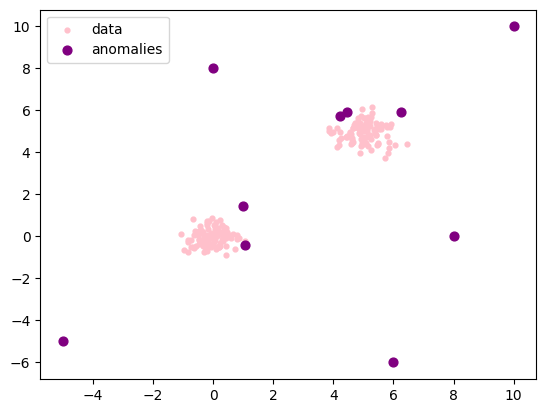

In [19]:
import matplotlib.pyplot as plt

# plot data and highlight anomalies
plt.scatter(X[:,0], X[:,1], s=12, label='data', c='Pink')
plt.scatter(X[order[:10],0], X[order[:10],1], c='Purple', s=40, label='anomalies')
plt.legend()
plt.show()

---

## AI Usage Documentation

In accordance with the [AI policy](https://cogsys.uni-bamberg.de/teaching/ki-richtlinie.html), I declare that **Claude AI** (Anthropic) was used during the completion of this assignment for the following purposes:

### How Claude was used:

- **Syntax assistance**: Help with Python syntax, numpy operations, and pandas DataFrame manipulations
- **Concept explanations**: Understanding of concepts such as:
  - Information Gain and Entropy calculations
  - ID3 algorithm implementation details
  - K-fold cross-validation methodology
  - FoilGain formula and its components
- **Debugging support**: Assistance with fixing type hints and compatibility issues
- **Code structure**: Guidance on implementing the DecisionTree class and helper functions

### What was implemented by me:

- All final code implementations
- Comments and documentation throughout the notebook
- Analysis and interpretation of results
- Discussion of metrics and model performance

All code was written with my understanding and I can explain every part of the implementation.
